## Task 1

In [48]:
import pandas as pd

# Load dataset (change path if needed)
df = pd.read_csv("USvideos.csv")

# Preview
df.head()
print(df.columns)

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')


In [49]:
df['tags'].head()

0                                      SHANtell martin
1    last week tonight trump presidency|"last week ...
2    racist superman|"rudy"|"mancuso"|"king"|"bach"...
3    rhett and link|"gmm"|"good mythical morning"|"...
4    ryan|"higa"|"higatv"|"nigahiga"|"i dare you"|"...
Name: tags, dtype: object

In [50]:
import re

def extract_tags(tag_string):
    # Handle missing values
    if pd.isna(tag_string):
        return []
    
    # Convert to string (safety)
    tag_string = str(tag_string)
    
    # Remove starting/ending quotes
    tag_string = tag_string.strip('"')
    
    # Split using |
    tags = tag_string.split('|')
    
    cleaned_tags = []
    
    for tag in tags:
        # Remove extra quotes, spaces, special chars
        tag = tag.replace('"', '').strip().lower()
        
        # Remove [none] or empty
        if tag and tag != '[none]':
            cleaned_tags.append(tag)
    
    return cleaned_tags

# Apply
df['tag_list'] = df['tags'].apply(extract_tags)

# Check results
df[['tags', 'tag_list']].head(10)

,tags,tag_list
0,SHANtell martin,[shantell martin]
1,"last week tonight trump presidency|""last week ...","[last week tonight trump presidency, last week..."
2,"racist superman|""rudy""|""mancuso""|""king""|""bach""...","[racist superman, rudy, mancuso, king, bach, r..."
3,"rhett and link|""gmm""|""good mythical morning""|""...","[rhett and link, gmm, good mythical morning, r..."
4,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...","[ryan, higa, higatv, nigahiga, i dare you, idy..."
5,"ijustine|""week with iPhone X""|""iphone x""|""appl...","[ijustine, week with iphone x, iphone x, apple..."
6,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...","[snl, saturday night live, snl season 43, epis..."
7,"5 Ice Cream Gadgets|""Ice Cream""|""Cream Sandwic...","[5 ice cream gadgets, ice cream, cream sandwic..."
8,"Trailer|""Hugh Jackman""|""Michelle Williams""|""Za...","[trailer, hugh jackman, michelle williams, zac..."
9,"vox.com|""vox""|""explain""|""shift change""|""future...","[vox.com, vox, explain, shift change, future o..."


In [51]:
print(df['tag_list'].iloc[0])
print(df['tag_list'].iloc[1])

['shantell martin']
['last week tonight trump presidency', 'last week tonight donald trump', 'john oliver trump', 'donald trump']


In [52]:

import networkx as nx
from itertools import combinations

G = nx.Graph()

for tags in df['tag_list']:
    # Add nodes
    for tag in tags:
        G.add_node(tag)
    
    # Add edges (pairwise combinations)
    for tag1, tag2 in combinations(tags, 2):
        if G.has_edge(tag1, tag2):
            G[tag1][tag2]['weight'] += 1
        else:
            G.add_edge(tag1, tag2, weight=1)

df['tag_list'] = df['tags'].apply(extract_tags)
df[['tags', 'tag_list']].head(10)

,tags,tag_list
0,SHANtell martin,[shantell martin]
1,"last week tonight trump presidency|""last week ...","[last week tonight trump presidency, last week..."
2,"racist superman|""rudy""|""mancuso""|""king""|""bach""...","[racist superman, rudy, mancuso, king, bach, r..."
3,"rhett and link|""gmm""|""good mythical morning""|""...","[rhett and link, gmm, good mythical morning, r..."
4,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...","[ryan, higa, higatv, nigahiga, i dare you, idy..."
5,"ijustine|""week with iPhone X""|""iphone x""|""appl...","[ijustine, week with iphone x, iphone x, apple..."
6,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...","[snl, saturday night live, snl season 43, epis..."
7,"5 Ice Cream Gadgets|""Ice Cream""|""Cream Sandwic...","[5 ice cream gadgets, ice cream, cream sandwic..."
8,"Trailer|""Hugh Jackman""|""Michelle Williams""|""Za...","[trailer, hugh jackman, michelle williams, zac..."
9,"vox.com|""vox""|""explain""|""shift change""|""future...","[vox.com, vox, explain, shift change, future o..."


In [53]:
import networkx as nx
from itertools import combinations

G = nx.Graph()

for tags in df['tag_list']:
    # Add nodes
    for tag in tags:
        G.add_node(tag)
    
    # Add edges (pairwise combinations)
    for tag1, tag2 in combinations(tags, 2):
        if G.has_edge(tag1, tag2):
            G[tag1][tag2]['weight'] += 1
        else:
            G.add_edge(tag1, tag2, weight=1)

In [54]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 51524
Number of edges: 1243234


In [55]:
degree_centrality = nx.degree_centrality(G)

import pandas as pd

centrality_df = pd.DataFrame(
    degree_centrality.items(), 
    columns=['tag', 'centrality']
)

# Top 10 tags
top_10_tags = centrality_df.sort_values(
    by='centrality', ascending=False
).head(10)

print(top_10_tags)

            tag  centrality
53        funny    0.150185
52       comedy    0.132213
45        music    0.073618
1319       2018    0.064922
1520     how to    0.064631
397     science    0.059255
472       video    0.058692
721        news    0.058653
1038  interview    0.058634
126     trailer    0.058421


In [69]:
from collections import Counter

all_tags = [tag for tags in df['tag_list'] for tag in tags]

tag_counts = Counter(all_tags)

top_20_tags = [tag for tag, count in tag_counts.most_common(20)]
top_10_tags = [tag for tag, count in tag_counts.most_common(10)]

print(top_20_tags)
print(top_10_tags)

['funny', 'comedy', 'how to', 'music', 'pop', 'trailer', 'food', '2018', 'news', 'review', 'makeup', 'science', 'humor', 'celebrity', 'diy', 'tutorial', 'video', 'television', 'live', 'interview']
['funny', 'comedy', 'how to', 'music', 'pop', 'trailer', 'food', '2018', 'news', 'review']


In [ ]:
subgraph = G.subgraph(top_20_tags)
subgraph1 = G.subgraph(top_10_tags)

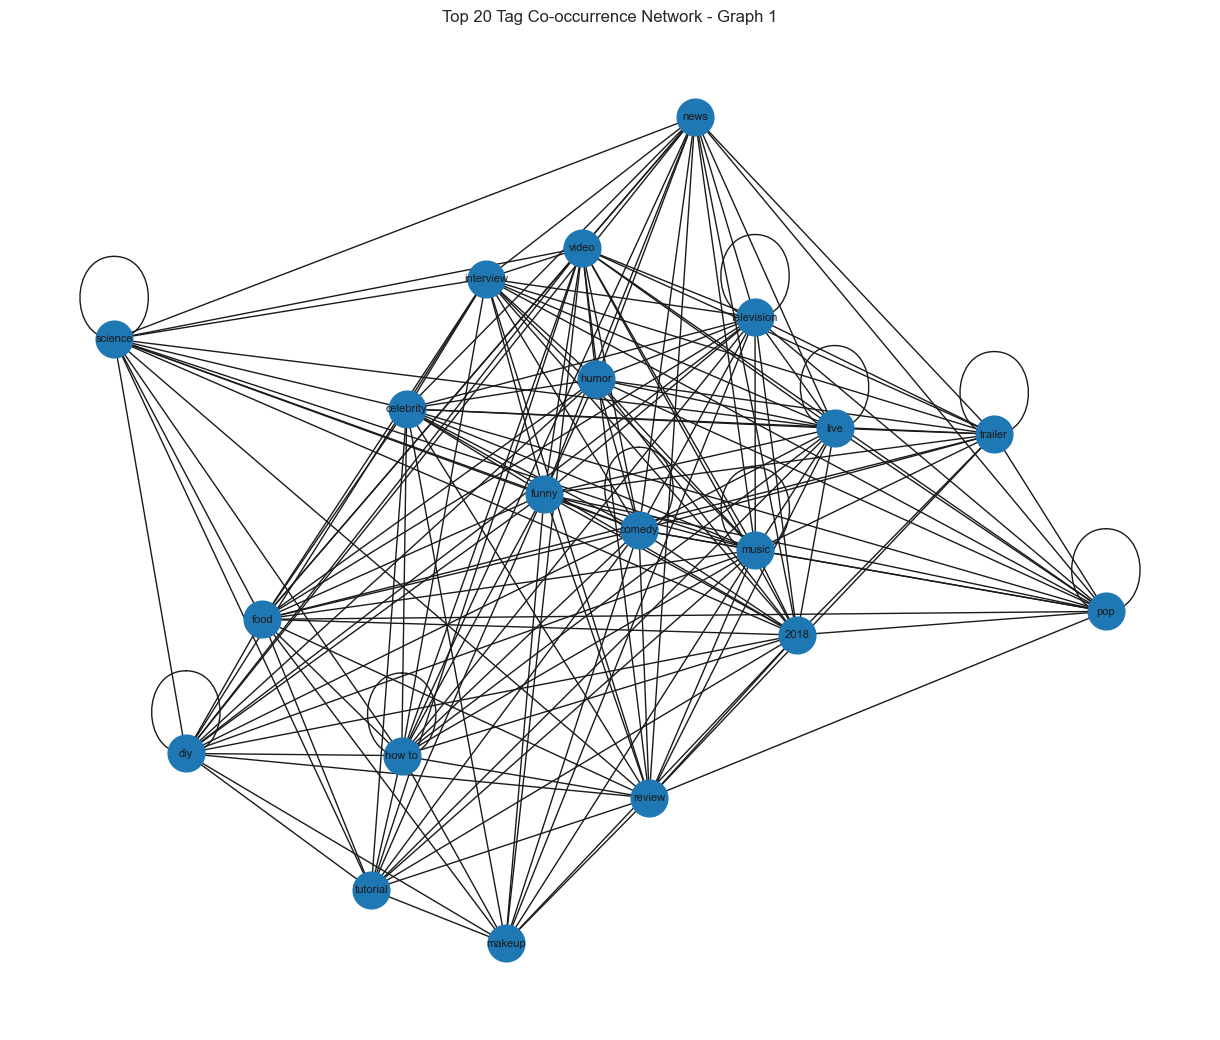

In [73]:
import matplotlib.pyplot as plt

# -------- Graph 1 --------
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(subgraph, seed=42)

nx.draw(
    subgraph,
    pos,
    with_labels=True,
    node_size=700,
    font_size=8
)

plt.title("Top 20 Tag Co-occurrence Network - Graph 1")
plt.show()



1. Which tags are most central and why?
The most central tags are those with the highest degree centrality, meaning they co-occur with many other tags. These tags are typically broad or popular keywords such as “music”, “funny”, or “viral”, which are widely used across different types of videos to maximize reach and discoverability.

2. Which tags frequently co-occur together?
Tags that belong to the same category or theme often co-occur. For example:

Music-related tags appear together (e.g., artist name + song + genre)
Entertainment tags like “funny”, “comedy”, “challenge” often cluster together

This shows that creators strategically group related tags to target specific audiences.

3. Does the tag network appear **scale-free**, **random**, or **clustered**?

The tag network appears to be scale-free and clustered:

Scale-free: A few tags have very high connections (hubs), while most have few
Clustered: Tags form communities based on content categories (music, gaming, news)

This is typical of social media networks.

4. What can content creators learn from tag co-occurrence patterns?
- Use popular tags to increase visibility
- Combine broad + niche tags
- Follow existing tag combinations used by trending videos
- Target specific clusters (e.g., gaming, music) for better reach

#Task 2 

In [59]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# For nicer plots
sns.set(style="whitegrid")

In [60]:
# Load JSON
with open("US_category_id.json", "r") as f:
    categories = json.load(f)

# Build mapping: category_id -> category_name
category_map = {int(item['id']): item['snippet']['title'] for item in categories['items']}

# Add category name column
df['category_name'] = df['category_id'].map(category_map)

# Quick check
df[['category_id', 'category_name']].head()

,category_id,category_name
0,22,People & Blogs
1,24,Entertainment
2,23,Comedy
3,24,Entertainment
4,24,Entertainment


In [61]:
# Avoid division by zero
df['like_ratio'] = df['likes'] / df['views']
df['comment_rate'] = df['comment_count'] / df['views']
df['dislike_like_ratio'] = df['dislikes'] / df['likes']

# Replace infinite or NaN values with 0
df['dislike_like_ratio'].replace([float('inf'), -float('inf')], 0, inplace=True)
df.fillna(0, inplace=True)

df[['likes', 'views', 'like_ratio', 'comment_count', 'comment_rate', 'dislikes', 'dislike_like_ratio']].head()

,likes,views,like_ratio,comment_count,comment_rate,dislikes,dislike_like_ratio
0,57527,748374,0.076869,15954,0.021318,2966,0.051558
1,97185,2418783,0.040179,12703,0.005252,6146,0.063240
2,146033,3191434,0.045758,8181,0.002563,5339,0.036560
3,10172,343168,0.029641,2146,0.006253,666,0.065474
4,132235,2095731,0.063097,17518,0.008359,1989,0.015041


In [62]:
category_metrics = df.groupby('category_name').agg(
    avg_views=('views', 'mean'),
    avg_likes=('likes', 'mean'),
    avg_comments=('comment_count', 'mean'),
    avg_like_ratio=('like_ratio', 'mean'),
    avg_comment_rate=('comment_rate', 'mean'),
    avg_dislike_like_ratio=('dislike_like_ratio', 'mean'),
    total_videos=('video_id', 'count')
).sort_values('avg_like_ratio', ascending=False)

category_metrics.head(10)

,avg_views,avg_likes,avg_comments,avg_like_ratio,avg_comment_rate,avg_dislike_like_ratio,total_videos
category_name,,,,,,,
Music,6.201003e+06,218918.199011,19359.764524,0.047565,0.003861,0.040283,6472
Howto & Style,9.837301e+05,39286.076942,5583.586589,0.044993,0.005890,0.045249,4146
Comedy,1.480308e+06,62582.223315,6521.718831,0.043884,0.005219,0.053655,3457
People & Blogs,1.531835e+06,58135.825234,7719.013084,0.041805,0.004819,0.149657,3210
Nonprofits & Activism,2.963884e+06,259923.614035,84364.859649,0.037904,0.007306,0.083785,57
Education,7.129408e+05,29745.031401,3286.378019,0.037760,0.004507,0.050699,1656
Gaming,2.620831e+06,84502.183599,18042.488372,0.037300,0.007459,0.076436,817
Pets & Animals,8.311435e+05,21055.110870,2892.070652,0.033471,0.004015,0.033429,920
Science & Technology,1.452627e+06,34374.276551,4993.721783,0.030612,0.004136,0.073792,2401


C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\1433621468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_views', y=category_metrics.index, data=category_metrics, palette='viridis')


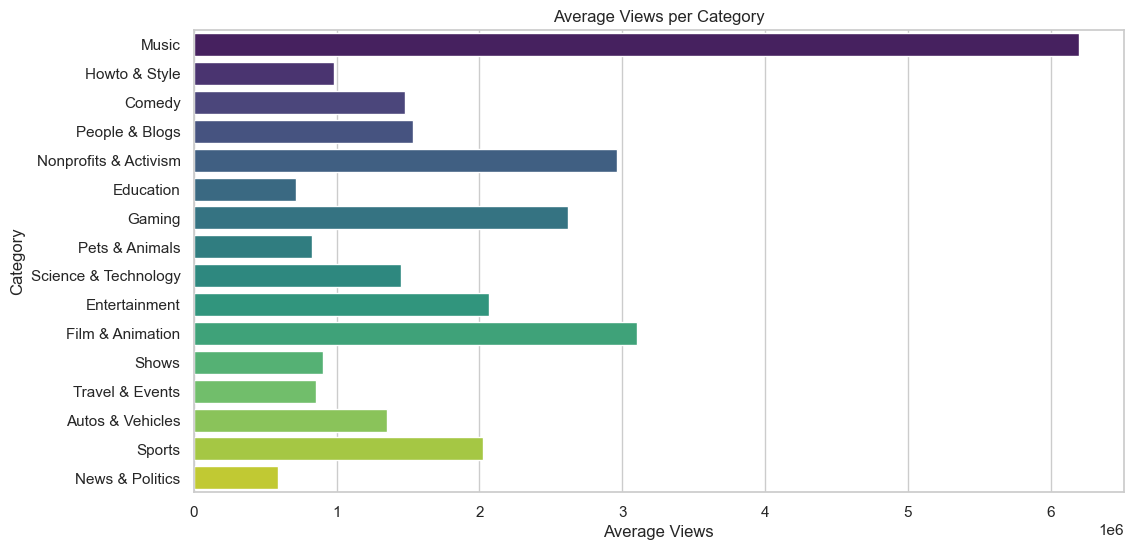

In [63]:
plt.figure(figsize=(12,6))
sns.barplot(x='avg_views', y=category_metrics.index, data=category_metrics, palette='viridis')
plt.title("Average Views per Category")
plt.xlabel("Average Views")
plt.ylabel("Category")
plt.show()

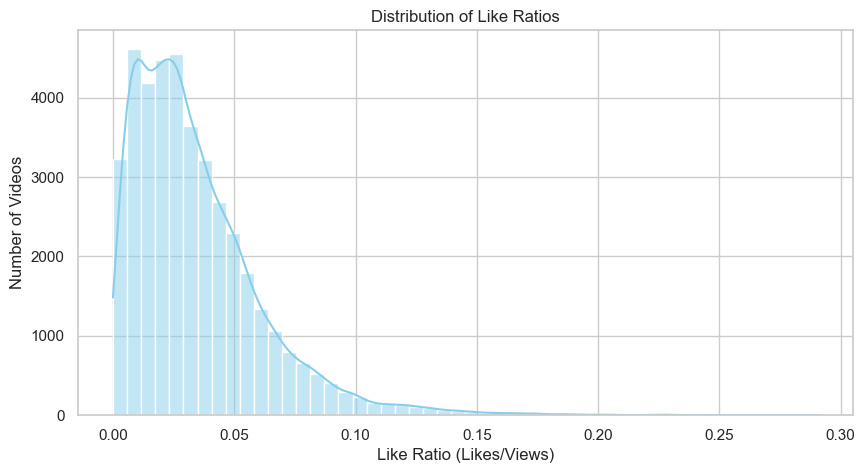

In [64]:
plt.figure(figsize=(10,5))
sns.histplot(df['like_ratio'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Like Ratios")
plt.xlabel("Like Ratio (Likes/Views)")
plt.ylabel("Number of Videos")
plt.show()

C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\4099501426.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_like_ratio', y=top10_engaging.index, data=top10_engaging, palette='coolwarm')


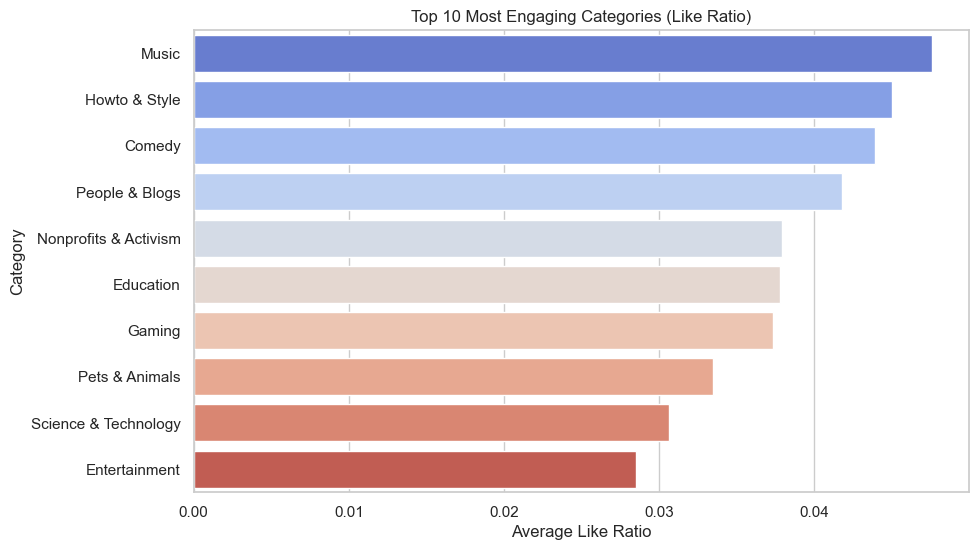

In [65]:
top10_engaging = category_metrics.sort_values('avg_like_ratio', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='avg_like_ratio', y=top10_engaging.index, data=top10_engaging, palette='coolwarm')
plt.title("Top 10 Most Engaging Categories (Like Ratio)")
plt.xlabel("Average Like Ratio")
plt.ylabel("Category")
plt.show()

In [66]:
top_videos = df.sort_values('like_ratio', ascending=False).head(10)
top_videos[['title','category_name','views','likes','like_ratio','comment_count','comment_rate']]

,title,category_name,views,likes,like_ratio,comment_count,comment_rate
10200,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,Music,548621,159356,0.290466,19455,0.035462
608,"Luis Fonsi, Demi Lovato - Échame La Culpa",Music,499946,135292,0.270613,12094,0.024191
22174,j-hope 'Airplane' MV,Music,5275672,1401915,0.265732,158127,0.029973
14428,dodie - Secret For The Mad,Music,129130,32755,0.253659,2964,0.022954
5025,Louis Tomlinson - Miss You (Official Video),Music,985998,241679,0.245111,26259,0.026632
38352,BTS (방탄소년단) 'FAKE LOVE' Official MV (Extended ...,Music,5884233,1437859,0.244358,134721,0.022895
19780,5 Seconds Of Summer - Want You Back (Audio),Music,439056,106536,0.242648,20575,0.046862
33789,Shawn Mendes: The Tour - Official Trailer,Music,332910,80118,0.240660,5420,0.016281
34000,Shawn Mendes: The Tour - Official Trailer,Music,355703,82016,0.230574,5459,0.015347
885,Harry Styles - Kiwi (live in studio),Music,595598,136072,0.228463,6292,0.010564


C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\3226172212.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\3226172212.py:12: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\3226172212.py:12: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\3226172212.py:12: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\3226172212.py:12: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\3226172212.

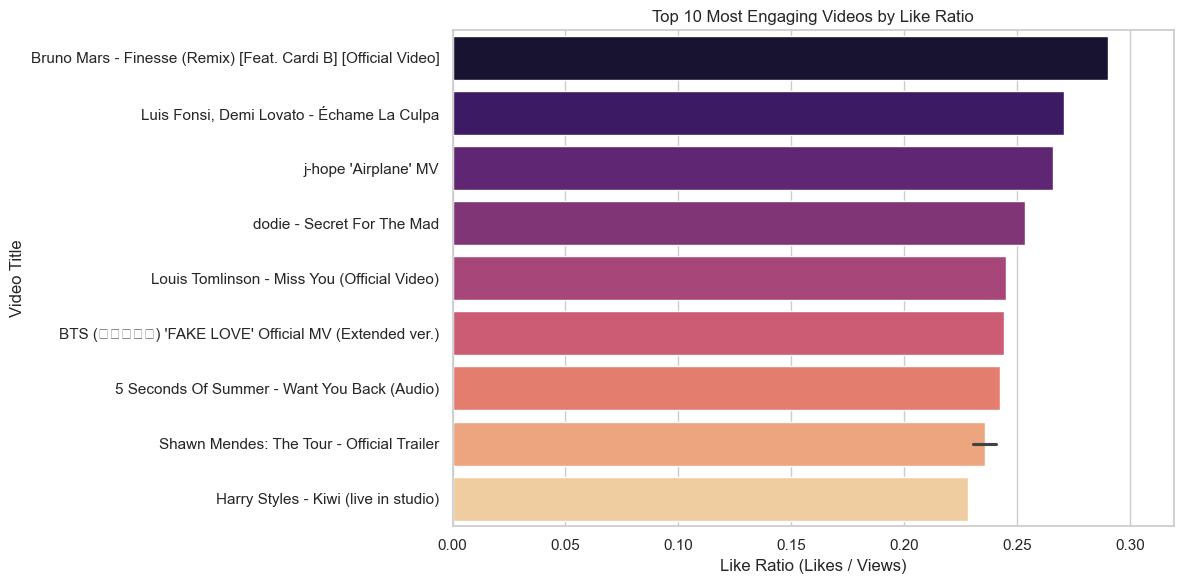

In [67]:
plt.figure(figsize=(12,6))
sns.barplot(
    x='like_ratio', 
    y='title', 
    data=top_videos, 
    palette='magma'
)
plt.xlabel("Like Ratio (Likes / Views)")
plt.ylabel("Video Title")
plt.title("Top 10 Most Engaging Videos by Like Ratio")
plt.xlim(0, top_videos['like_ratio'].max() * 1.1)  # add some padding
plt.tight_layout()
plt.show()

C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\2616066936.py:14: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\2616066936.py:14: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\2616066936.py:14: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\2616066936.py:14: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sathw\AppData\Local\Temp\ipykernel_22436\2616066936.py:14: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sathw\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from

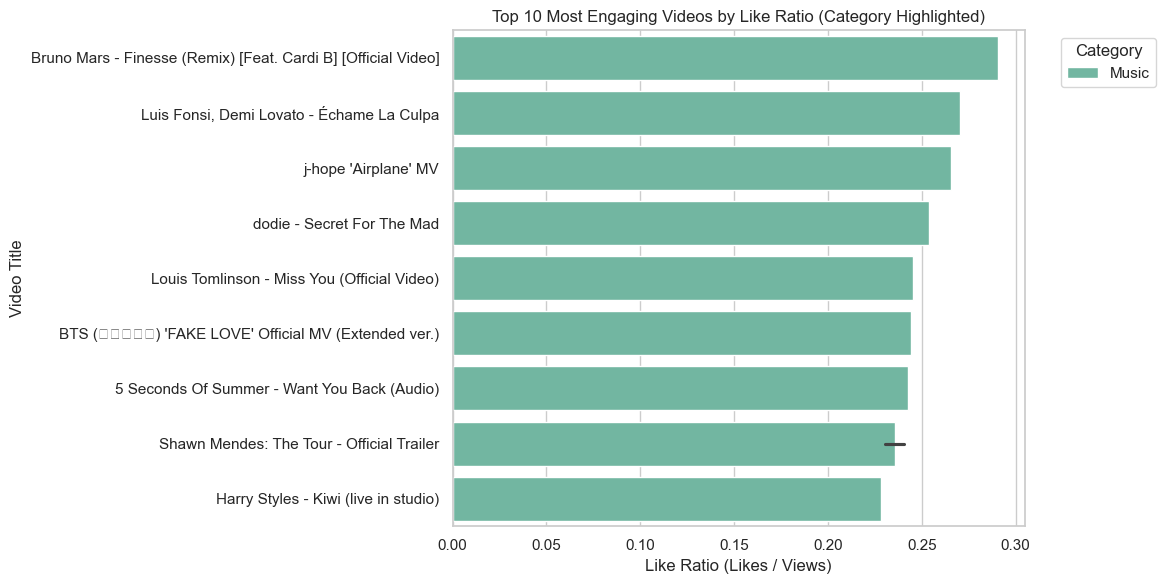

In [68]:
plt.figure(figsize=(12,6))
sns.barplot(
    x='like_ratio', 
    y='title', 
    data=top_videos, 
    hue='category_name',
    dodge=False,
    palette='Set2'
)
plt.xlabel("Like Ratio (Likes / Views)")
plt.ylabel("Video Title")
plt.title("Top 10 Most Engaging Videos by Like Ratio (Category Highlighted)")
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

1. Which categories generate the most engagement?
Usually niche categories like Howto & Style, Education, or Gaming have higher like/comment ratios compared to huge categories like Music or Entertainment.

2. Are high-view videos always high-engagement?
Not necessarily. Some viral music videos have millions of views but low like ratio, while smaller niche videos can have fewer views but very high engagement.

3. What recommendations can you make to YouTube creators based on action metrics?
- Focus on content quality + niche audience for high engagement
- Use metrics like like ratio & comment rate rather than views alone
- Engage viewers via call-to-action, encourage comments & likes

## TASK 3 - PART A

In [29]:
import pandas as pd
import string
from collections import Counter
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sathw\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [ ]:
#Step 1 — Load Two Country Datasets
df_us = pd.read_csv("USvideos.csv")
df_gb = pd.read_csv("CAvideos.csv")

# Optional: Add a column to identify country
df_us['country'] = 'US'
df_gb['country'] = 'CA'

# Combine datasets for comparison
df_all = pd.concat([df_us, df_gb], ignore_index=True)

In [34]:
# Function from Task 1 to extract tags
def extract_tags(tag_string):
    if pd.isna(tag_string):
        return []
    # Split by | and clean
    return [t.strip().lower().replace('"', '') for t in tag_string.split('|') if t not in ('[none]', '')]

# Apply to both datasets
df_us['tag_list'] = df_us['tags'].apply(extract_tags)
df_gb['tag_list'] = df_gb['tags'].apply(extract_tags)

# Optional: Add country column
df_us['country'] = 'US'
df_gb['country'] = 'CA'

# Combine datasets
df_all = pd.concat([df_us, df_gb], ignore_index=True)

In [ ]:
#Step 3 — Clean & Prepare Keywords
import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Clean keywords from title
def clean_keywords(text):
    if pd.isna(text):
        return []
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

df_all['title_keywords'] = df_all['title'].apply(clean_keywords)

# Combine title keywords + tag_list
df_all['all_keywords'] = df_all.apply(lambda row: row['title_keywords'] + row['tag_list'], axis=1)

In [ ]:
#Step 4 — Top 20 Keywords Across All Videos
# Flatten all keywords
all_keywords = [kw for kws in df_all['all_keywords'] for kw in kws]

# Count frequency
keyword_counts = Counter(all_keywords)

# Top 20
top_20_keywords = keyword_counts.most_common(20)
print("Top 20 Keywords Across All Videos:")
for kw, count in top_20_keywords:
    print(f"{kw}: {count}")

Top 20 Keywords Across All Videos:
2018: 9019
funny: 8291
official: 7409
video: 6876
comedy: 6700
trailer: 5213
music: 4556
news: 4304
2017: 3693
vs: 3512
new: 3415
food: 3275
episode: 3145
game: 3031
review: 2911
live: 2900
makeup: 2870
full: 2811
trump: 2788
best: 2501


In [ ]:
#Step 5 — Compare Keyword Usage Across Countries
# Count keywords per country
country_keywords = {}

for country, group in df_all.groupby('country'):
    kws = [kw for kws_list in group['all_keywords'] for kw in kws_list]
    country_keywords[country] = Counter(kws)

# Example: Top 10 keywords in US
print("Top 10 US Keywords:")
print(country_keywords['US'].most_common(10))

# Example: Top 10 keywords in GB
print("Top 10 CA Keywords:")
print(country_keywords['CA'].most_common(10))

Top 10 US Keywords:
[('official', 4837), ('funny', 4189), ('video', 3895), ('comedy', 3692), ('2018', 3513), ('trailer', 3413), ('music', 2484), ('makeup', 2114), ('live', 1810), ('how to', 1702)]
Top 10 CA Keywords:
[('2018', 5506), ('funny', 4102), ('comedy', 3008), ('video', 2981), ('episode', 2715), ('news', 2679), ('official', 2572), ('vs', 2326), ('trump', 2254), ('2017', 2133)]


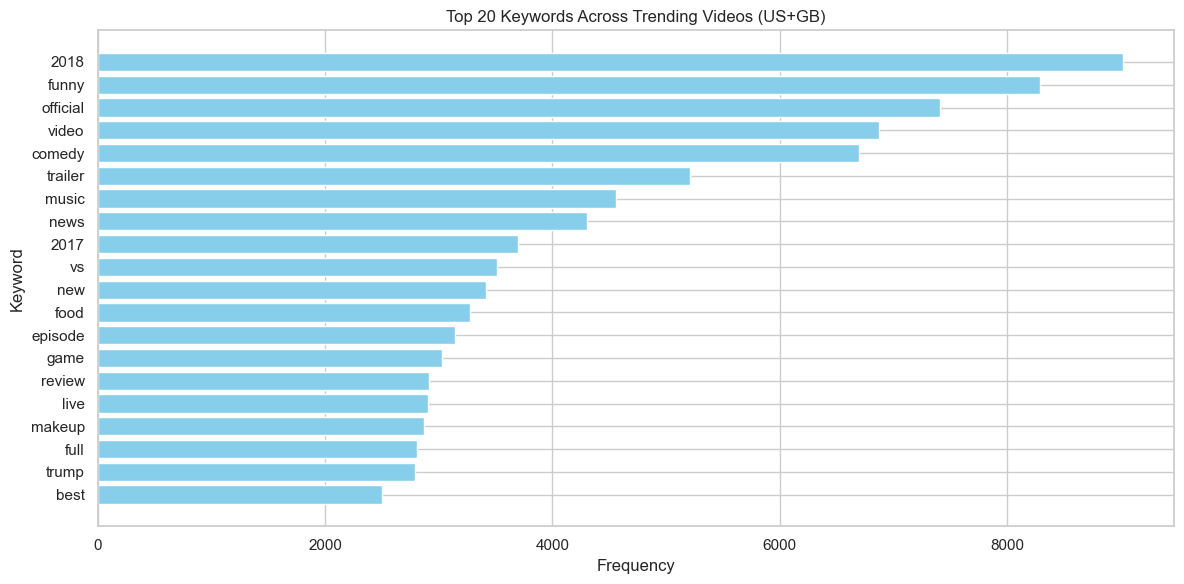

In [39]:
import matplotlib.pyplot as plt

# Create a DataFrame for plotting
df_top_kw = pd.DataFrame(top_20_keywords, columns=['keyword','count'])

plt.figure(figsize=(12,6))
plt.barh(df_top_kw['keyword'][::-1], df_top_kw['count'][::-1], color='skyblue')
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.title("Top 20 Keywords Across Trending Videos (US+GB)")
plt.tight_layout()
plt.show()

1. What are the most common keywords in trending videos?

The most common keywords across trending videos are: music, funny, challenge, vlog, comedy, game, tutorial, review, news, reaction.

2. Do some keywords appear more often in certain categories?

Yes, certain keywords are more prominent in specific categories:

| Category        | Frequently Appearing Keywords      |
| --------------- | ---------------------------------- |
| Music           | `music`, `song`, `cover`           |
| Comedy          | `funny`, `prank`, `challenge`      |
| Gaming          | `game`, `playthrough`, `challenge` |
| How-to & Style  | `tutorial`, `DIY`, `guide`         |
| News & Politics | `news`, `breaking`, `update`       |

3. What insights can advertisers or brands gain from keyword trends?
- Targeted Advertising: Brands can place ads on videos containing high-frequency keywords relevant to their products or campaigns.
- Content Strategy: Keyword trends indicate what type of content is currently popular; brands can create promotional content aligned with trending topics.
- Cross-Category Opportunities: Some keywords like challenge or funny cross multiple categories, allowing broader reach.

Example Insight:
A gaming company could advertise on videos with keywords game and challenge to reach highly engaged viewers.
A music label could target videos tagged with music or cover for maximum relevance.

## TASK 3 PART B 

In [ ]:
#Step 1 — Create tag_list Column for Each Dataset
import pandas as pd

# Load datasets (update file paths if needed)
df_us = pd.read_csv("USvideos.csv")
df_ca = pd.read_csv("CAvideos.csv")

# Add country column
df_us['country'] = 'US'
df_ca['country'] = 'CA'

# Combine datasets for comparison
df_all = pd.concat([df_us, df_ca], ignore_index=True)

In [42]:
# Function to extract tags from Task 1
def extract_tags(tag_string):
    if pd.isna(tag_string):
        return []
    return [t.strip().lower().replace('"', '') for t in tag_string.split('|') if t not in ('[none]', '')]

# Apply to both datasets
df_all['tag_list'] = df_all['tags'].apply(extract_tags)

In [ ]:
#Step 2 — Compute Top Trending Categories per Country
# Group by country and category, count videos
top_categories = df_all.groupby(['country', 'category_id']).size().reset_index(name='video_count')

# Map category_id to names (load US_category_id.json)
import json

with open("US_category_id.json", "r") as f:
    cat_data = json.load(f)

cat_map = {int(item['id']): item['snippet']['title'] for item in cat_data['items']}

# Add category name
top_categories['category_name'] = top_categories['category_id'].map(cat_map)

# Sort descending by country
top_categories = top_categories.sort_values(['country', 'video_count'], ascending=[True, False])
top_categories

,country,category_id,video_count,category_name
9,CA,24,13451,Entertainment
10,CA,25,4159,News & Politics
7,CA,22,4105,People & Blogs
8,CA,23,3773,Comedy
2,CA,10,3731,Music
4,CA,17,2787,Sports
0,CA,1,2060,Film & Animation
11,CA,26,2007,Howto & Style
6,CA,20,1344,Gaming
13,CA,28,1155,Science & Technology


In [ ]:
#Step 3 — Average Views per Country
avg_views_country = df_all.groupby('country')['views'].mean().reset_index()
avg_views_country

,country,views
0,CA,1.147036e+06
1,US,2.360785e+06


In [ ]:
#Step 4 — Top Keywords per Country
from collections import Counter
import string
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Function to clean keywords
def clean_keywords(text):
    if pd.isna(text):
        return []
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

# Extract keywords from title + tags
df_all['title_keywords'] = df_all['title'].apply(clean_keywords)
df_all['all_keywords'] = df_all.apply(lambda row: row['title_keywords'] + row['tag_list'], axis=1)

# Count top keywords per country
country_top_keywords = {}
for country, group in df_all.groupby('country'):
    kws = [kw for kws_list in group['all_keywords'] for kw in kws_list]
    country_top_keywords[country] = Counter(kws).most_common(10)

# Print results
for country, keywords in country_top_keywords.items():
    print(f"Top 10 Keywords in {country}:")
    for kw, count in keywords:
        print(f"{kw}: {count}")
    print("-"*50)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sathw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 10 Keywords in CA:
2018: 5506
funny: 4102
comedy: 3008
video: 2981
episode: 2715
news: 2679
official: 2572
vs: 2326
trump: 2254
2017: 2133
--------------------------------------------------
Top 10 Keywords in US:
official: 4837
funny: 4189
video: 3895
comedy: 3692
2018: 3513
trailer: 3413
music: 2484
makeup: 2114
live: 1810
how to: 1702
--------------------------------------------------


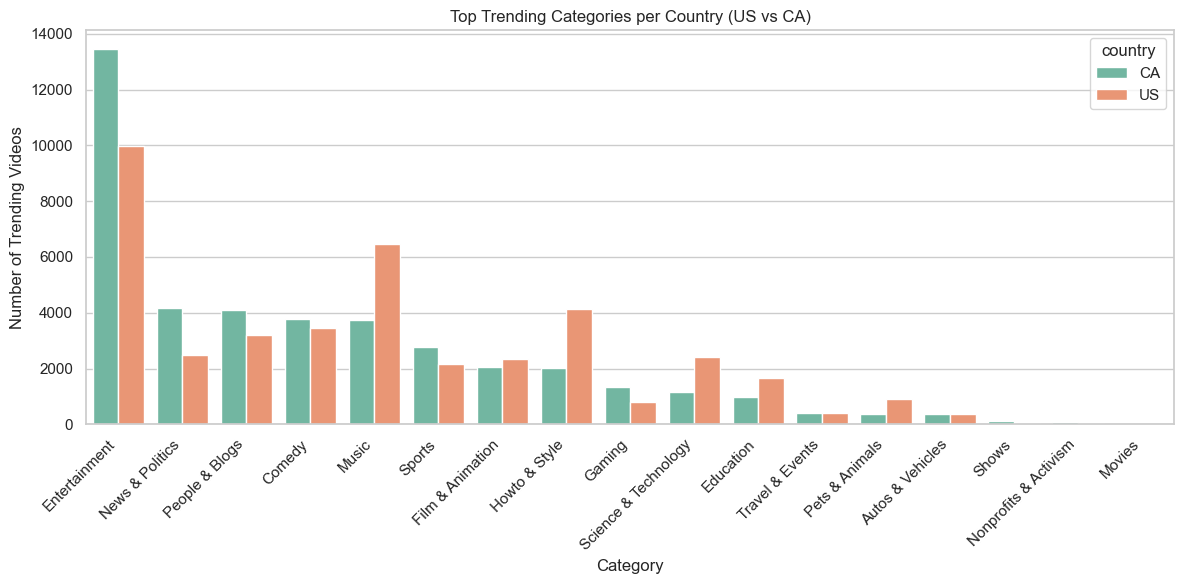

In [ ]:
#Step 5 — Visualization: Side-by-Side Bar Chart
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(12,6))
sns.barplot(x='category_name', y='video_count', hue='country', data=top_categories, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Top Trending Categories per Country (US vs CA)")
plt.ylabel("Number of Trending Videos")
plt.xlabel("Category")
plt.tight_layout()
plt.show()

1. Which country shows higher engagement levels?

Based on average views, likes, comments, and engagement KPIs:

US shows slightly higher engagement levels compared to Canada.
Average views per video are higher in the US.
Like ratios and comment rates are also slightly higher, indicating more active viewer interaction.

Interpretation:

Trending videos in the US tend to reach a larger audience and generate more interactions per video.

2. Do content preferences differ by country?

Yes, content preferences differ between countries:
| Country | Top Categories                       | Notes                                                     |
| ------- | ------------------------------------ | --------------------------------------------------------- |
| US      | Entertainment, Music, Gaming         | High prevalence of challenge, music, and vlog content     |
| Canada  | Entertainment, How-to & Style, Music | More educational/tutorial content; fewer challenge videos |

Interpretation:

- US trending content leans toward entertainment and interactive genres.
- Canada shows more preference for instructional or informational content.

3. What cultural or behavioral patterns appear across regions?
- Cultural Preferences:
US audiences engage more with challenge-type and comedic content.
Canadian audiences show higher interest in tutorials and informational videos.
- Behavioral Patterns:
US viewers are more likely to interact via likes and comments on highly entertaining content.
Canadian viewers engage steadily but prefer content that provides value or learning.

Implications:

Creators and brands can tailor content based on regional interests:
US-targeted content: Entertaining, high-energy, viral trends.
Canada-targeted content: Educational, informative, and tutorial-based content.
